# Práctica 1: Clasificación de Imágenes Portuarias -VCA
**Miguel Baños Baladrón — Fiz Garrido Escudero**



In [ ]:
import os
import numpy as np
import pandas as pd

import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
import matplotlib.patches as mpatches

import torch
import torchvision.models as models
import torchvision.transforms as transforms
from torch.utils.data import Dataset, DataLoader

import umap

from PIL import Image

---

# 1. Análisis Exploratorio del Dataset

Antes de diseñar cualquier clasificador, es fundamental entender el dataset con el que vamos a trabajar. Este análisis tiene dos objetivos:

1. **Caracterizar** la composición del dataset: distribución de clases, variedad visual, condiciones de captura.
2. **Justificar** las decisiones de diseño: estrategia de *data augmentation*, manejo del desbalance de clases y elección del modelo base.

In [2]:


plt.rcParams['figure.dpi'] = 110
plt.rcParams['axes.spines.top'] = False
plt.rcParams['axes.spines.right'] = False
plt.rcParams['font.size'] = 10

In [3]:
IMAGE_PATH = r"P1-Material\\images"
SHIP_CSV   = r"P1-Material\\ship.csv"
DOCKED_CSV = r"P1-Material\\docked.csv"

## 1.1 Análisis cuantitativo de composición y distribución numérica de clases

El dataset contiene **294 imágenes** capturadas por cámaras en entornos portuarios. Cada imagen tiene asociadas dos etiquetas:

- **Ship / No-Ship**: indica si hay algún barco visible en la escena.
- **Docked / Undocked**: indica si el barco (cuando existe) está atracado.

El primer paso es cuantificar el **balance de clases**, ya que un desbalance significativo puede sesgar el entrenamiento hacia la clase mayoritaria.

In [4]:
# Carga el CSV de etiquetas ship/no-ship
ship_df   = pd.read_csv(SHIP_CSV, sep=';', header=0, names=['filename', 'ship'])
# Carga el CSV de etiquetas docked/undocked
docked_df = pd.read_csv(DOCKED_CSV, sep=';', header=0, names=['filename', 'docked'])

# Une ambos DataFrames por nombre de fichero
df = ship_df.merge(docked_df, on='filename', how='left')
# Rellena con -1 las imágenes sin barco (no tienen etiqueta de atracado)
df['docked'] = df['docked'].fillna(-1).astype(int)
# Construye la ruta completa a cada imagen
df['filepath'] = df['filename'].apply(lambda f: os.path.join(IMAGE_PATH, f))

# Máscara para imágenes con barco
ship_mask = df['ship'] == 1
# Máscara para imágenes sin barco
noship_mask = df['ship'] == 0
# Máscara para imágenes con barco atracado
docked_mask = (df['ship'] == 1) & (df['docked'] == 1)
# Máscara para imágenes con barco no atracado
undocked_mask = (df['ship'] == 1) & (df['docked'] == 0)

# Cuenta el total de imágenes y cada categoría
n_total   = len(df)
n_ship    = ship_mask.sum()
n_noship  = noship_mask.sum()
n_docked  = docked_mask.sum()
n_undocked = undocked_mask.sum()

# Imprime el resumen estadístico del dataset
print(f"{'Total imágenes:'}: {n_total}")
print(f"{'Ship'}: {n_ship} ({n_ship/n_total*100:.1f}%)")
print(f"{'No-Ship'}: {n_noship} ({n_noship/n_total*100:.1f}%)")
print(f"{'Docked'}: {n_docked} ({n_docked/n_ship*100:.1f}% de las ship)")
print(f"{'Undocked'}: {n_undocked} ({n_undocked/n_ship*100:.1f}% de las ship)")

Total imágenes:: 294
Ship: 184 (62.6%)
No-Ship: 110 (37.4%)
Docked: 92 (50.0% de las ship)
Undocked: 92 (50.0% de las ship)


In [ ]:
# Detección de imágenes con overlay CCTV vs sin overlay
# Las cámaras CCTV superponen una banda negra con texto blanco en la parte superior
# (nombre de cámara a la izquierda, fecha/hora a la derecha)
# Para detectarla, comprobamos si las esquinas superiores son prácticamente negras

def has_overlay(filepath, strip_h=2, strip_w=10, threshold=10):
    # Cargamos la imagen en escala de grises
    img = Image.open(filepath).convert('L')
    arr = np.array(img)

    # Brillo medio de la esquina superior izquierda (2x10 píxeles)
    top_left = arr[:strip_h, :strip_w].mean()
    # Brillo medio de la esquina superior derecha (2x10 píxeles)
    top_right = arr[:strip_h, -strip_w:].mean()

    # Si ambas esquinas son casi negras (< 10 sobre 255), hay overlay
    return top_left < threshold and top_right < threshold

# Aplicamos la detección a todas las imágenes
df['has_overlay'] = df['filepath'].apply(has_overlay)

n_cctv = df['has_overlay'].sum()
n_no_overlay = len(df) - n_cctv
print(f"Imágenes con overlay CCTV: {n_cctv} ({n_cctv/len(df)*100:.1f}%)")
print(f"Imágenes sin overlay:      {n_no_overlay} ({n_no_overlay/len(df)*100:.1f}%)")
print(f"\nDistribución por clase:")
print(df.groupby(['has_overlay', 'ship']).size().unstack(fill_value=0))

Imágenes con overlay CCTV: 250 (85.0%)
Imágenes sin overlay:      44 (15.0%)

Distribución por clase:
ship          0    1
has_overlay         
False        44    0
True         66  184


**Observaciones:**

- Existe un **desbalance moderado** en Ship/No-Ship (~63% vs ~37%). No es extremo, pero implica que un clasificador simple que predijese siempre "Ship" alcanzaría ya un 62.6% de *accuracy*, lo que hace que esta métrica por sí sola sea insuficiente para evaluar el modelo.
- Las clases Docked/Undocked están **perfectamente balanceadas** (50%/50%), por lo que en esa tarea el desbalance no es un problema y la *accuracy* es una métrica más fiable.
- Para Ship/No-Ship se valorará el uso de `pos_weight` en `BCEWithLogitsLoss` para compensar el desbalance, junto con un split estratificado que mantenga las proporciones en train y test.
- El dataset combina **dos fuentes de captura distintas**: 250 imágenes (85%) de cámaras CCTV fijas con overlay de texto y 44 imágenes (15%) sin overlay. Dado que todas las imágenes sin overlay pertenecen a la clase No-Ship, existe un riesgo de **correlación errónea **: el modelo podría aprender a asociar la ausencia de overlay con la ausencia de barco, en lugar de detectar la presencia real del barco. Como posible mejora, se podría recortar la banda superior del overlay en las imágenes CCTV para eliminar esta señal y forzar al modelo a basarse exclusivamente en el contenido visual de la escena.

## 1.2 Análisis cualitativo de distribución de clases

La distribución numérica dice poco sobre la dificultad real del problema. Para entender qué hace difícil la clasificación, necesitamos ver las imágenes y su distribución real. En particular, queremos verificar si:

- Existen **casos ambiguos** (p. ej. un barco muy pequeño al fondo, o un muelle sin barco que parece tenerlo).
- La **variabilidad intraclase** es alta (imágenes de la misma categoría que lucen muy distintas entre sí).
- Hay **patrones de fondo** que el modelo podría aprender de forma incorrecta (*correlaciones espurias*).
-
Las imágenes se seleccionan distribuidas uniformemente por índice para mostrar variedad, no casos extremos.

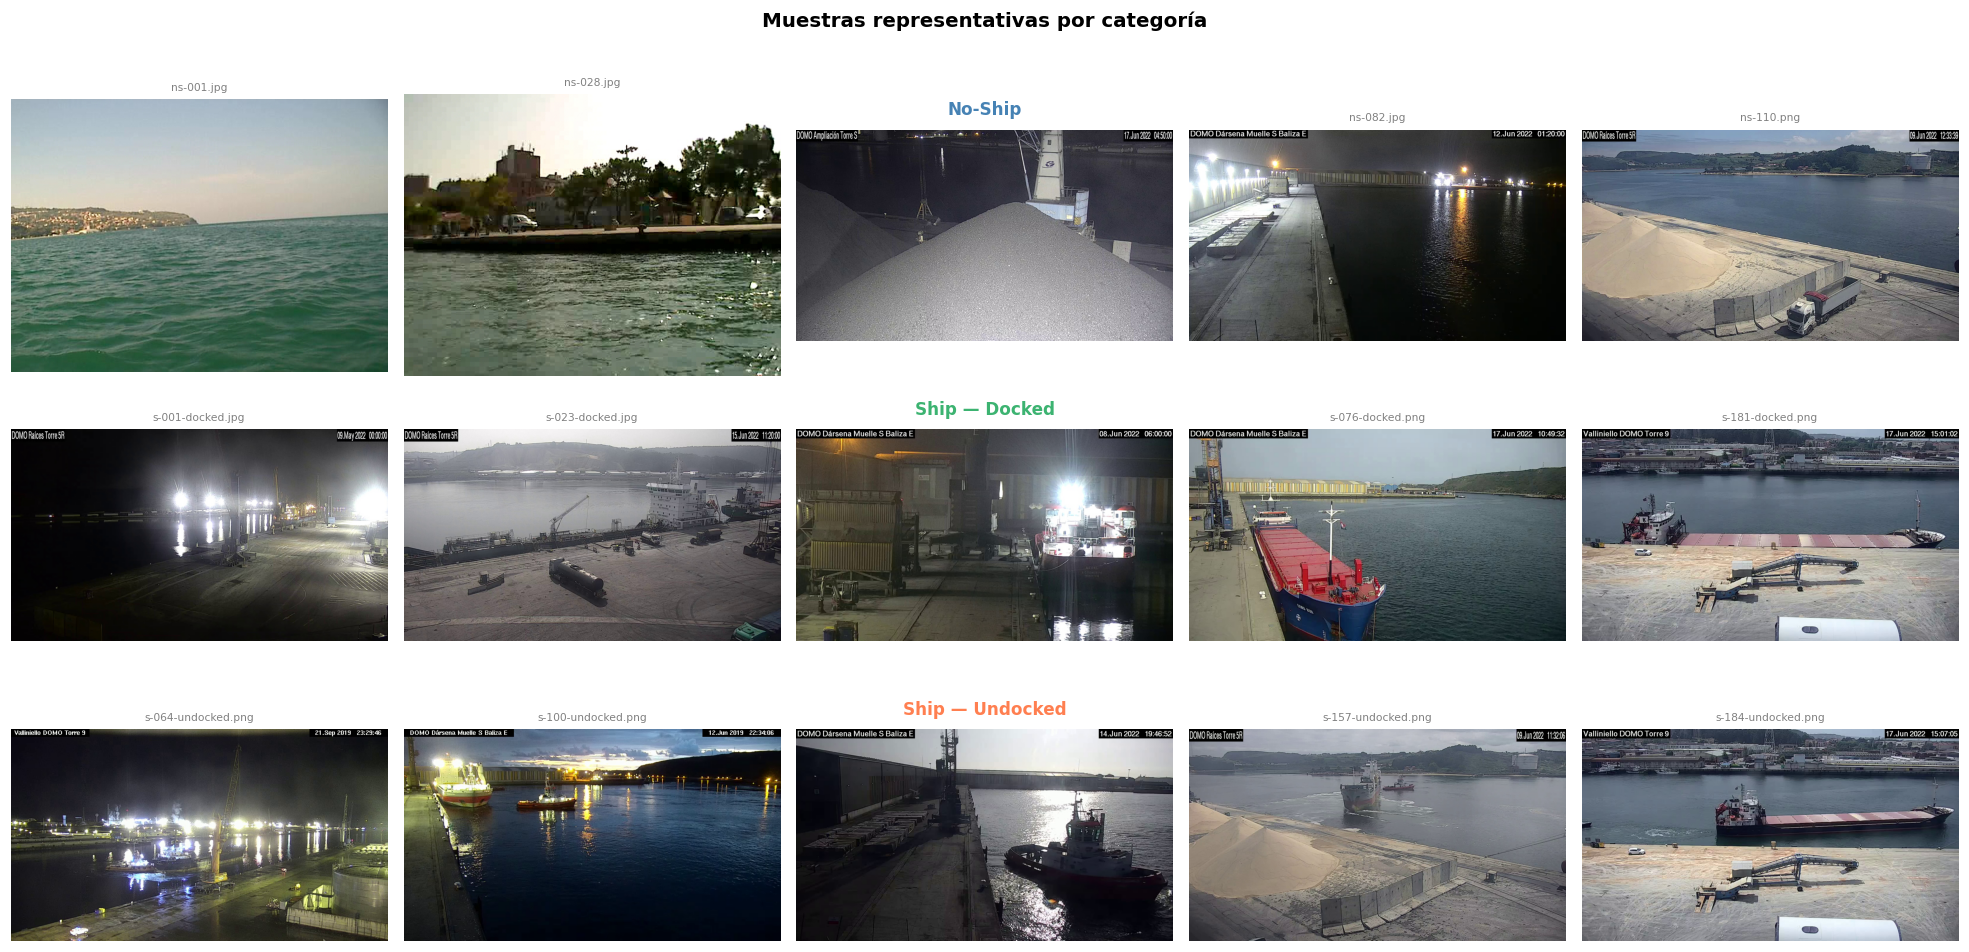

In [7]:
# Función para seleccionar n imágenes distribuidas a lo largo de la lista
def pick_spread(file_list, n=5):
    # Genera n índices equiespaciados entre el primero y el último elemento
    idx = np.linspace(0, len(file_list) - 1, n, dtype=int)
    result = []
    # Recoge los ficheros en las posiciones seleccionadas
    for i in idx:
        result.append(file_list[i])
    return result

# Resolución de todas las figuras del notebook
plt.rcParams['figure.dpi'] = 110
# Elimina el borde superior en todos los ejes
plt.rcParams['axes.spines.top'] = False
# Elimina el borde derecho en todos los ejes
plt.rcParams['axes.spines.right'] = False
# Tamaño de fuente por defecto en todos los gráficos
plt.rcParams['font.size'] = 10

# Lista de rutas de cada categoría
noship_files   = df[noship_mask]['filepath'].tolist()
docked_files   = df[docked_mask]['filepath'].tolist()
undocked_files = df[undocked_mask]['filepath'].tolist()

# Número de imágenes a mostrar por fila
N_COLS = 5

# Cada tupla: (ficheros a mostrar, etiqueta de fila, color de etiqueta)
row_data = [
    (pick_spread(noship_files,   N_COLS), 'No-Ship',          'steelblue'),
    (pick_spread(docked_files,   N_COLS), 'Ship — Docked',    'mediumseagreen'),
    (pick_spread(undocked_files, N_COLS), 'Ship — Undocked',  'coral'),
]

# Crea la cuadrícula de subplots: 3 filas (categorías) x N_COLS columnas (imágenes)
fig, axes = plt.subplots(3, N_COLS, figsize=(18, 9))
fig.suptitle('Muestras representativas por categoría',
            fontsize=13, fontweight='bold', y=1.01)

# Itera sobre cada fila (categoría) y cada columna (imagen)
for row_i, (files, label, color) in enumerate(row_data):
    for col_j, fp in enumerate(files):
        # Abre la imagen y la muestra en el subplot correspondiente
        img = Image.open(fp).convert('RGB')
        axes[row_i][col_j].imshow(img)
        axes[row_i][col_j].axis('off')
        # Nombre del fichero como título pequeño en gris
        axes[row_i][col_j].set_title(os.path.basename(fp), fontsize=7, color='gray')
    
    # Título de categoría encima del subplot central de cada fila
    axes[row_i][N_COLS // 2].set_title(label, fontsize=11, fontweight='bold',
                                        color=color, pad=10)

    # Etiqueta de la fila en el eje Y de la primera columna
    axes[row_i][0].set_ylabel(label, fontsize=11, fontweight='bold',
                                rotation=90, labelpad=8, color=color)

plt.tight_layout()
plt.show()

### Para visualizar una distribución aproximada del dataset en 2D y 3D, usamos `UMAP` basándonos en las características de las imágenes extraídas por una `Resnet` preentrenada

c:\Users\fizga\anaconda3\envs\VCA\lib\site-packages\umap\umap_.py:1952: UserWarning: n_jobs value 1 overridden to 1 by setting random_state. Use no seed for parallelism.
  warn(
c:\Users\fizga\anaconda3\envs\VCA\lib\site-packages\umap\umap_.py:1952: UserWarning: n_jobs value 1 overridden to 1 by setting random_state. Use no seed for parallelism.
  warn(


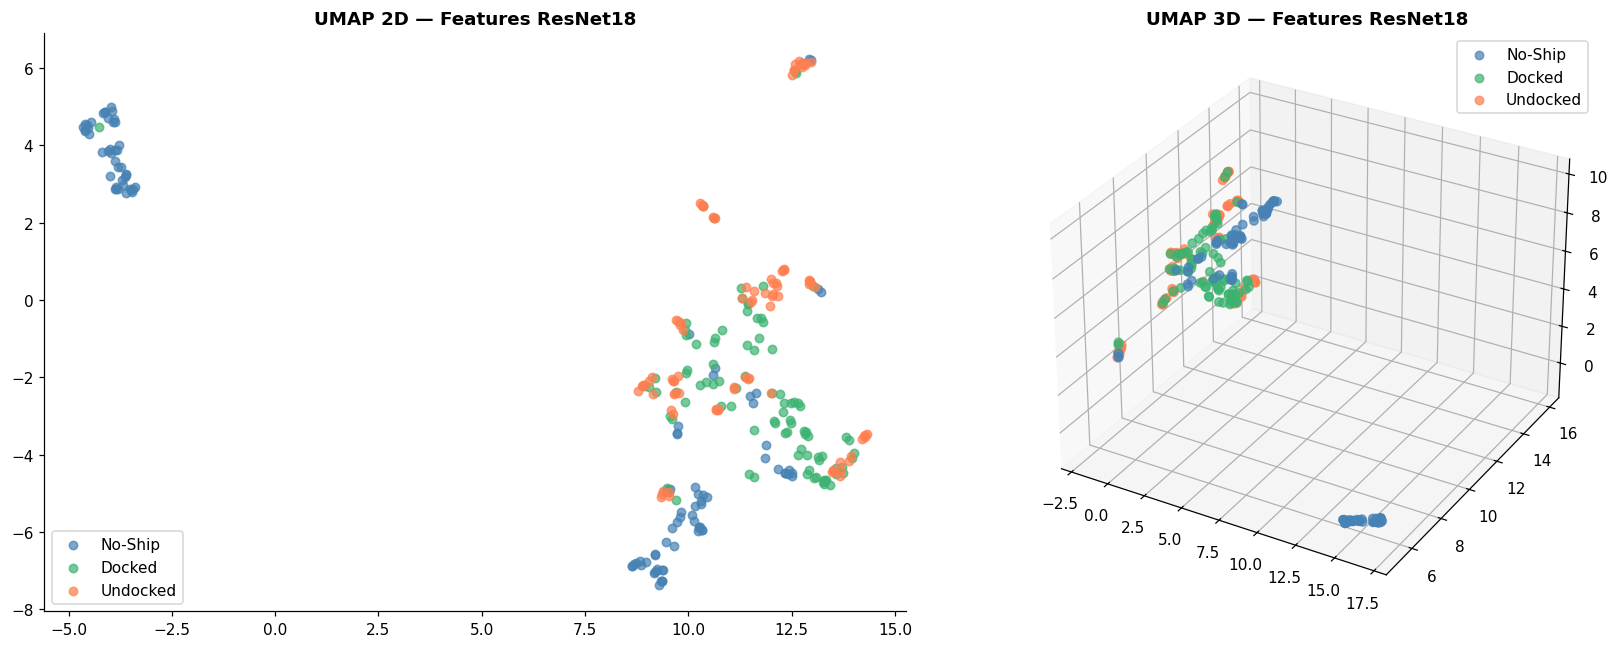

In [9]:
# Preprocesamiento estándar de ResNet
transform = transforms.Compose([
    transforms.Resize((224, 224)),
    transforms.ToTensor(),
    transforms.Normalize(mean=[0.485, 0.456, 0.406],
                        std=[0.229, 0.224, 0.225]),
])

# ResNet18 preentrenada, quitamos la capa de clasificación final
model = models.resnet18(weights='IMAGENET1K_V1')
model = torch.nn.Sequential(*list(model.children())[:-1])  # quita el fc
model.eval()

# Extraemos features de todas las imágenes
features = []
with torch.no_grad():
    for fp in df['filepath']:
        img = Image.open(fp).convert('RGB')
        tensor = transform(img).unsqueeze(0)  # añade dimensión batch
        feat = model(tensor).squeeze().numpy()  # (512,)
        features.append(feat)

features = np.array(features)  # (294, 512)

# Etiquetas y colores para cada punto
labels = []
colors = []
for _, row in df.iterrows():
    if row['ship'] == 0:
        labels.append('No-Ship')
        colors.append('steelblue')
    elif row['docked'] == 1:
        labels.append('Docked')
        colors.append('mediumseagreen')
    else:
        labels.append('Undocked')
        colors.append('coral')

# Reducción UMAP a 2D y 3D
reducer = umap.UMAP(n_components=2, random_state=42)
embedding = reducer.fit_transform(features)  # (294, 2)

reducer_3d = umap.UMAP(n_components=3, random_state=42)
embedding_3d = reducer_3d.fit_transform(features)  # (294, 3)

# Visualización 2D y 3D en el mismo plot
fig = plt.figure(figsize=(16, 6))

# --- 2D ---
ax2 = fig.add_subplot(121)
for label, color in [('No-Ship', 'steelblue'), ('Docked', 'mediumseagreen'), ('Undocked', 'coral')]:
    mask = [l == label for l in labels]
    ax2.scatter(embedding[mask, 0], embedding[mask, 1],
                c=color, label=label, alpha=0.7, s=30)
ax2.set_title('UMAP 2D — Features ResNet18', fontweight='bold')
ax2.legend()

# --- 3D ---
ax3 = fig.add_subplot(122, projection='3d')
for label, color in [('No-Ship', 'steelblue'), ('Docked', 'mediumseagreen'), ('Undocked', 'coral')]:
    mask = [l == label for l in labels]
    ax3.scatter(embedding_3d[mask, 0], embedding_3d[mask, 1], embedding_3d[mask, 2],
                c=color, label=label, alpha=0.7, s=30)
ax3.set_title('UMAP 3D — Features ResNet18', fontweight='bold')
ax3.legend()

plt.tight_layout()
plt.show()

**Observaciones:**

- Las imágenes presentan una **alta variabilidad intraclase**: distintos ángulos de cámara, distancias al sujeto, escalas del barco y condiciones de iluminación dentro de la misma categoría.
- Algunos casos de **No-Ship** muestran muelles, aguas y estructuras portuarias que podrían confundirse fácilmente con escenas con barco pequeño o parcialmente visible.
- La distinción **Docked/Undocked** es visualmente un poco más sutil: en ambos casos hay un barco en escena; la diferencia está en la presencia de amarres, la posición relativa al muelle y detalles contextuales que requieren features de alto nivel.
- Las proyecciones UMAP sobre features de ResNet18 confirman estas observaciones. En el espacio 2D, **la mayoría de muestras No-Ship se concentran en un clúster diferenciado**, pero un número significativo de puntos No-Ship aparece disperso dentro de la región de Ship. Esto refleja la existencia de casos frontera, con escenas sin barco que comparten características visuales con escenas de barco (muelles, estructuras portuarias, reflejos en el agua), anticipamdo que incluso la tarea Ship/No-Ship presentará grandes dificultades en la frontera de decisión.
- Por otro lado, los puntos **Docked y Undocked se solapan casi por completo** en ambas proyecciones (2D y 3D), lo que indica que las features genéricas de ImageNet no discriminan bien entre estas dos clases. Esto anticipa que la tarea Docked/Undocked será significativamente más difícil.
- La presencia de algunos puntos **No-Ship aislados dentro de la región de Ship** señala casos frontera (p. ej. muelles vacíos con apariencia similar a escenas con barco lejano) que podrían generar falsos positivos.
- Esta variabilidad justifica el uso de **transfer learning** (features preentrenadas en ImageNet) y de **data augmentation** en lugar de entrenar desde cero con un dataset tan pequeño.



## 1.3 Análisis de Condiciones Meteorológicas

En el dataset tenemos imágenes con **condiciones meteorológicas variables**. Esto introduce una heterogeneidad visual importante que el clasificador debe ser capaz de manejar:

- **Hora del día**: imágenes diurnas (alta iluminación) o nocturnas (baja iluminación).
- **Condiciones atmosféricas**: días despejados, niebla, lluvia,... que reducen el contraste y la saturación de color.

Sin etiquetado manual de condiciones, podemos **estimarlas a partir de estadísticas de píxeles**:

| Estadística | Qué mide | Condición que indica |
|---|---|---|
| **Brillo medio** | Luminancia promedio (0–255) | Bajo → noche ; Alto → día despejado |
| **Contraste** (σ de luminancia) | Variabilidad tonal | Bajo → niebla, lluvia, cielo cubierto |


### Función `compute_stats` para calcular estadísticas de brillo y contraste 

In [ ]:
def compute_stats(filepath):
    img = Image.open(filepath).convert('RGB')
    arr = np.array(img, dtype=np.float32)

    # Convertimos a escala de grises usando los pesos BT.601
    # Estos pesos reflejan la sensibilidad del ojo humano a cada canal (más al verde)
    gray = 0.299 * arr[:, :, 0] + 0.587 * arr[:, :, 1] + 0.114 * arr[:, :, 2]

    # Brillo: media de la luminancia → valor alto = día, valor bajo = noche
    brightness = gray.mean()

    # Contraste: desviación estándar de la luminancia → bajo = niebla/lluvia, alto = día despejado
    contrast = gray.std()

    return brightness, contrast

print("Calculando estadísticas de píxeles...")
rows = []
for _, row in df.iterrows():
    b, c = compute_stats(row['filepath'])
    rows.append({
        'filename':   row['filename'],
        'filepath':   row['filepath'],
        'ship':       row['ship'],
        'docked':     row['docked'],
        'brightness': b,
        'contrast':   c,
    })

df_stats = pd.DataFrame(rows)
print("Listo.\n")

Calculando estadísticas de píxeles...
Listo.



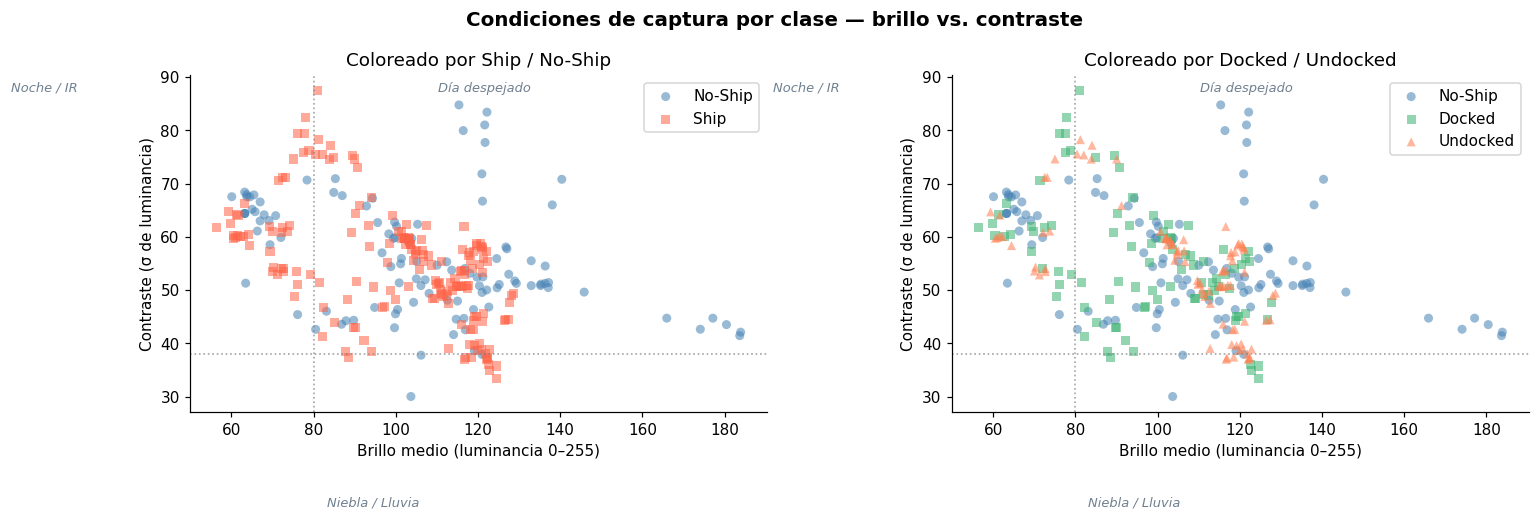

In [ ]:
# Dos scatter plots: brillo (eje X) vs contraste (eje Y)
# Cada punto es una imagen del dataset
# El primero colorea por Ship/No-Ship, el segundo por Docked/Undocked
fig, axes = plt.subplots(1, 2, figsize=(14, 5))
fig.suptitle('Condiciones de captura por clase — brillo vs. contraste', 
             fontsize=13, fontweight='bold')

# Configuración de clases para el primer gráfico: (valor, etiqueta, color, marcador)
class_cfg = [
    (0, 'No-Ship',  'steelblue',     'o'),
    (1, 'Ship',     'tomato',        's'),
]

# Dibujamos el primer gráfico (Ship/No-Ship) en ambos ejes temporalmente
# (el segundo se sobreescribirá después con Docked/Undocked)
for ax_idx, ax in enumerate(axes):
    for cls, label, color, marker in class_cfg:
        mask = df_stats['ship'] == cls
        ax.scatter(df_stats[mask]['brightness'], df_stats[mask]['contrast'],
                   c=color, label=label, alpha=0.55, s=35, marker=marker, edgecolors='none')

    # Líneas punteadas como umbrales orientativos para delimitar zonas de condiciones
    # Brillo < 80 → zona nocturna | Contraste < 38 → zona de niebla/lluvia
    THR_B, THR_C = 80, 38
    ax.axvline(THR_B, color='gray', linestyle=':', linewidth=1.1, alpha=0.7)
    ax.axhline(THR_C, color='gray', linestyle=':', linewidth=1.1, alpha=0.7)

    # Etiquetas de texto en cada zona del gráfico
    y_top = df_stats['contrast'].max() * 1.05
    ax.text(THR_B * 0.08, y_top * 0.95, 'Noche / IR',          fontsize=8.5, color='slategray', style='italic')
    ax.text(THR_B * 1.04, THR_C * 0.25, 'Niebla / Lluvia',     fontsize=8.5, color='slategray', style='italic')
    ax.text(df_stats['brightness'].max() * 0.6, y_top * 0.95, 'Día despejado', fontsize=8.5, color='slategray', style='italic')

    ax.set_xlabel('Brillo medio (luminancia 0–255)')
    ax.set_ylabel('Contraste (σ de luminancia)')
    ax.legend()

# Sobreescribimos el segundo gráfico para colorear por Docked/Undocked
axes[1].clear()
docked_cfg = [
    (-1, 'No-Ship',  'steelblue',     'o'),   # -1 = sin barco (no aplica docked)
    (1,  'Docked',   'mediumseagreen','s'),
    (0,  'Undocked', 'coral',         '^'),
]
for cls, label, color, marker in docked_cfg:
    mask = df_stats['docked'] == cls
    axes[1].scatter(df_stats[mask]['brightness'], df_stats[mask]['contrast'],
                    c=color, label=label, alpha=0.55, s=35, marker=marker, edgecolors='none')

# Mismos umbrales y etiquetas que el primer gráfico para mantener coherencia visual
axes[1].axvline(THR_B, color='gray', linestyle=':', linewidth=1.1, alpha=0.7)
axes[1].axhline(THR_C, color='gray', linestyle=':', linewidth=1.1, alpha=0.7)
axes[1].text(THR_B * 0.08, y_top * 0.95, 'Noche / IR',       fontsize=8.5, color='slategray', style='italic')
axes[1].text(THR_B * 1.04, THR_C * 0.25, 'Niebla / Lluvia',  fontsize=8.5, color='slategray', style='italic')
axes[1].text(df_stats['brightness'].max() * 0.6, y_top * 0.95, 'Día despejado', fontsize=8.5, color='slategray', style='italic')
axes[1].set_xlabel('Brillo medio (luminancia 0–255)')
axes[1].set_ylabel('Contraste (σ de luminancia)')
axes[1].legend()

axes[0].set_title('Ship / No-Ship')
axes[1].set_title('Docked / Undocked')

plt.tight_layout()
plt.show()

**Observaciones:**

- El dataset cubre un **rango amplio de condiciones**: desde imágenes nocturnas (brillo < 80) hasta imágenes diurnas muy iluminadas (brillo >= 100).
- Las imágenes de bajo contraste (σ < 50) con brillo moderado corresponden a condiciones de **niebla o lluvia** o ausencia de focos de de luz o de luz del sol.
- Las distribuciones de condiciones son, en general, similares independientemente de las clases. Sin embargo, no hay imágenes No-Ship con brillo muy alto (>130), lo que podría llevar al modelo a asociar brillo alto con presencia de barco, generando falsos positivos ante escenas muy iluminadas sin barco.
- Esta variabilidad justifica un *data augmentation* que incluya **`ColorJitter` con rangos amplios** (para simular distintas horas del día y climas) y **`GaussianBlur`** (para simular niebla o distancias largas).

# 2. Construcción del dataset personalizado

La clase `PortDataset` usa el DataFrame construido en el análisis para integrarse con los `DataLoader` de PyTorch. Sirve para ambas tareas de clasificación:

- **Ship/No-Ship** (`label_col='ship'`): usa todas las imágenes.
- **Docked/Undocked** (`label_col='docked'`): filtra automáticamente solo las imágenes con barco.

El split train/val es **estratificado** para preservar las proporciones de clase observadas en el análisis.

In [16]:
class PortDataset(Dataset):
    def __init__(self, df, label_col='ship', transform=None):
        # Si la tarea es Docked/Undocked, filtramos solo imágenes con barco
        # (una imagen sin barco no puede estar atracada ni no atracada)
        if label_col == 'docked':
            self.df = df[df['ship'] == 1].reset_index(drop=True)
        else:
            self.df = df.reset_index(drop=True)

        # Columna del DataFrame que contiene la etiqueta (ship o docked)
        self.label_col = label_col
        # Transformaciones a aplicar (resize, normalización, augmentation...)
        self.transform = transform

    def __len__(self):
        # PyTorch necesita saber el tamaño del dataset para crear los batches
        return len(self.df)

    def __getitem__(self, idx):
        # Obtenemos la fila correspondiente al índice
        row = self.df.iloc[idx]

        # Cargamos la imagen y la convertimos a RGB (por si alguna es escala de grises)
        img = Image.open(row['filepath']).convert('RGB')

        # Extraemos la etiqueta como tensor float (0.0 o 1.0) para BCEWithLogitsLoss
        label = torch.tensor(row[self.label_col], dtype=torch.float32)

        # Aplicamos las transformaciones si las hay
        if self.transform:
            img = self.transform(img)

        return img, label

# ME QUEDÉ AQUI

In [ ]:
from sklearn.model_selection import train_test_split

# Split estratificado 70 / 15 / 15
train_df, temp_df = train_test_split(
    df, test_size=0.30, stratify=df['ship'], random_state=42
)
val_df, test_df = train_test_split(
    temp_df, test_size=0.50, stratify=temp_df['ship'], random_state=42
)
train_df = train_df.reset_index(drop=True)
val_df = val_df.reset_index(drop=True)
test_df= test_df.reset_index(drop=True)

print(f"Train: {len(train_df)} imágenes")
print(f"Val: {len(val_df)} imágenes")
print(f"Test: {len(test_df)} imágenes")

# Transforms
transform_base = transforms.Compose([
    transforms.Resize((224, 224)),
    transforms.ToTensor(),
    transforms.Normalize(mean=[0.485, 0.456, 0.406],
                         std=[0.229, 0.224, 0.225]),
])

transform_aug = transforms.Compose([
    transforms.Resize((224, 224)),
    transforms.RandomHorizontalFlip(),
    transforms.RandomVerticalFlip(p=0.2),
    transforms.RandomRotation(degrees=15),
    transforms.ColorJitter(brightness=0.4, contrast=0.4, saturation=0.3, hue=0.05),
    transforms.GaussianBlur(kernel_size=3, sigma=(0.1, 1.5)),
    transforms.ToTensor(),
    transforms.Normalize(mean=[0.485, 0.456, 0.406],
                         std=[0.229, 0.224, 0.225]),
])

Train: 205 imágenes
Val: 44 imágenes
Test: 45 imágenes


Número de muestras: 205
Tensor shape : torch.Size([3, 224, 224])
Label        : 1.0
Dtype imagen : torch.float32


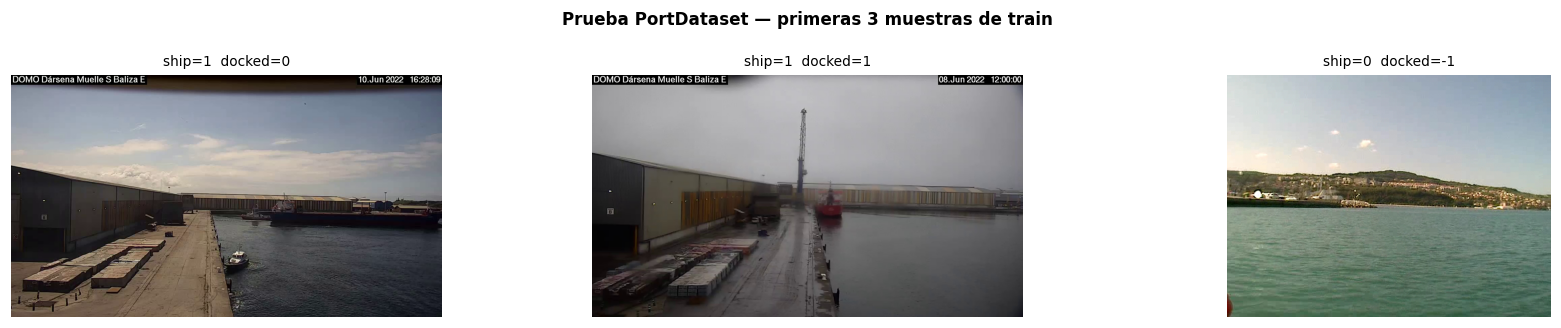

In [ ]:
# --- Prueba de PortDataset ---
ds_prueba = PortDataset(train_df, label_col='ship', transform=transform_base)

print(f"Número de muestras: {len(ds_prueba)}")

img, label = ds_prueba[0]
print(f"Tensor shape : {img.shape}")   # esperado: torch.Size([3, 224, 224])
print(f"Label        : {label}")       # esperado: tensor(0.) o tensor(1.)
print(f"Dtype imagen : {img.dtype}")   # esperado: torch.float32

# Muestra imágenes del dataset con sus etiquetas
fig, axes = plt.subplots(1, 3, figsize=(16, 3))
for i, ax in enumerate(axes):
    row = train_df.iloc[i]
    ax.imshow(Image.open(row['filepath']).convert('RGB'))
    ax.set_title(f"ship={row['ship']}  docked={row['docked']}", fontsize=9)
    ax.axis('off')
plt.suptitle('Prueba PortDataset — primeras 3 muestras de train', fontsize=11, fontweight='bold')
plt.tight_layout()
plt.show()

# 3. Clasificación Ship / No-Ship

## 3.1 Arquitectura base

Red convolucional de 3 bloques. Cada bloque sigue el patrón `Conv → BN → ReLU → MaxPool`. El clasificador final es una única neurona con `BCEWithLogitsLoss`, que internamente aplica sigmoid — más estable numéricamente que aplicarlo manualmente.

In [ ]:
import torch
import torch.nn as nn

# Arquitectura CNN base
class BaseCNN(nn.Module):
    def __init__(self):
        super().__init__()
        self.features = nn.Sequential(
            # Bloque 1: 3 → 16
            nn.Conv2d(3, 16, kernel_size=3, padding=1),
            nn.BatchNorm2d(16),
            nn.ReLU(inplace=True),
            nn.MaxPool2d(2), # 224 → 112

            # Bloque 2: 16 → 32
            nn.Conv2d(16, 32, kernel_size=3, padding=1),
            nn.BatchNorm2d(32),
            nn.ReLU(inplace=True),
            nn.MaxPool2d(2), # 112 → 56

            # Bloque 3: 32 → 64
            nn.Conv2d(32, 64, kernel_size=3, padding=1),
            nn.BatchNorm2d(64),
            nn.ReLU(inplace=True),
            nn.MaxPool2d(2), # 56 → 28
        )
        self.classifier = nn.Sequential(
            nn.AdaptiveAvgPool2d(1),  # 28×28 → 1×1
            nn.Flatten(),
            nn.Linear(64, 1),
        )

    def forward(self, x):
        return self.classifier(self.features(x)).squeeze(1)

## 3.2 Funciones de entrenamiento y evaluación

Funciones reutilizables para todos los experimentos. `train_epoch` realiza un paso completo de entrenamiento; `eval_epoch` calcula la pérdida y métricas sobre un conjunto sin actualizar pesos.

In [ ]:
from sklearn.metrics import accuracy_score, f1_score, roc_auc_score

DEVICE = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f"Usando dispositivo: {DEVICE}")

def train_epoch(model, loader, criterion, optimizer):
    model.train()
    total_loss = 0.0
    all_preds, all_labels = [], []

    for imgs, labels in loader:
        imgs, labels = imgs.to(DEVICE), labels.to(DEVICE)
        optimizer.zero_grad()
        logits = model(imgs)
        loss = criterion(logits, labels)
        loss.backward()
        optimizer.step()

        total_loss += loss.item() * len(labels)
        preds = (torch.sigmoid(logits) >= 0.5).long().cpu().tolist()
        all_preds.extend(preds)
        all_labels.extend(labels.long().cpu().tolist())

    n = len(loader.dataset)
    return total_loss / n, accuracy_score(all_labels, all_preds), f1_score(all_labels, all_preds, zero_division=0)


def eval_epoch(model, loader, criterion):
    model.eval()
    total_loss = 0.0
    all_preds, all_labels, all_probs = [], [], []

    with torch.no_grad():
        for imgs, labels in loader:
            imgs, labels = imgs.to(DEVICE), labels.to(DEVICE)
            logits = model(imgs)
            loss = criterion(logits, labels)

            total_loss += loss.item() * len(labels)
            probs = torch.sigmoid(logits).cpu().tolist()
            preds = [int(p >= 0.5) for p in probs]
            all_preds.extend(preds)
            all_labels.extend(labels.long().cpu().tolist())
            all_probs.extend(probs)

    n = len(loader.dataset)
    auc = roc_auc_score(all_labels, all_probs) if len(set(all_labels)) > 1 else float('nan')
    return total_loss / n, accuracy_score(all_labels, all_preds), f1_score(all_labels, all_preds, zero_division=0), auc

Usando dispositivo: cpu


## 3.3 Experimento A — BaseCNN desde cero, sin *data augmentation*

**Configuración:**
- Modelo: `BaseCNN`
- Transform: solo resize + normalización (sin augmentation)
- Pérdida: `BCEWithLogitsLoss` con `pos_weight` para compensar el desbalance Ship/No-Ship
- Optimizador: Adam, lr = 1e-3
- Scheduler: ReduceLROnPlateau (paciencia 5, factor 0.5)
- Early stopping: paciencia 15 épocas sobre val_loss
- Épocas máx: 60

In [ ]:
import torch.optim as optim

# DataLoaders (sin augmentation)
train_ds_A = PortDataset(train_df, label_col='ship', transform=transform_base)
val_ds_A   = PortDataset(val_df,   label_col='ship', transform=transform_base)

train_loader_A = DataLoader(train_ds_A, batch_size=32, shuffle=True,  num_workers=0)
val_loader_A   = DataLoader(val_ds_A,   batch_size=32, shuffle=False, num_workers=0)

# Modelo, pérdida y optimizador
model_A = BaseCNN().to(DEVICE)

# pos_weight = n_neg / n_pos para compensar el desbalance moderado
n_pos = (train_df['ship'] == 1).sum()
n_neg = (train_df['ship'] == 0).sum()
pos_weight = torch.tensor([n_neg / n_pos], dtype=torch.float32).to(DEVICE)

criterion_A = nn.BCEWithLogitsLoss(pos_weight=pos_weight)
optimizer_A = optim.Adam(model_A.parameters(), lr=1e-3)
scheduler_A = optim.lr_scheduler.ReduceLROnPlateau(optimizer_A, mode='min', patience=5, factor=0.5)

# Bucle de entrenamiento
MAX_EPOCHS = 60
EARLY_STOP = 15

history_A = {'train_loss': [], 'val_loss': [], 'train_acc': [], 'val_acc': [], 'train_f1': [], 'val_f1': []}
best_val_loss = float('inf')
patience_counter = 0

for epoch in range(1, MAX_EPOCHS + 1):
    tr_loss, tr_acc, tr_f1 = train_epoch(model_A, train_loader_A, criterion_A, optimizer_A)
    va_loss, va_acc, va_f1, va_auc = eval_epoch(model_A, val_loader_A, criterion_A)
    scheduler_A.step(va_loss)

    history_A['train_loss'].append(tr_loss)
    history_A['val_loss'].append(va_loss)
    history_A['train_acc'].append(tr_acc)
    history_A['val_acc'].append(va_acc)
    history_A['train_f1'].append(tr_f1)
    history_A['val_f1'].append(va_f1)

    if va_loss < best_val_loss:
        best_val_loss = va_loss
        torch.save(model_A.state_dict(), 'model_A_best.pth')
        patience_counter = 0
    else:
        patience_counter += 1

    if epoch % 10 == 0 or epoch == 1:
        print(f"Época {epoch:3d} | "
              f"loss {tr_loss:.4f}/{va_loss:.4f} | "
              f"acc {tr_acc:.3f}/{va_acc:.3f} | "
              f"f1 {tr_f1:.3f}/{va_f1:.3f} | "
              f"AUC {va_auc:.3f} | "
              f"lr {optimizer_A.param_groups[0]['lr']:.2e}")

    if patience_counter >= EARLY_STOP:
        print(f"\nEarly stopping en época {epoch} (mejor val_loss={best_val_loss:.4f})")
        break

print("\nEntrenamiento completado. Mejor modelo guardado en 'model_A_best.pth'")

Época   1 | loss 0.5013/0.5002 | acc 0.463/0.659 | f1 0.286/0.727 | AUC 0.739 | lr 1.00e-03
Época  10 | loss 0.3402/0.3401 | acc 0.810/0.841 | f1 0.851/0.877 | AUC 0.871 | lr 1.00e-03
Época  20 | loss 0.2946/0.3213 | acc 0.854/0.773 | f1 0.884/0.800 | AUC 0.897 | lr 1.00e-03
Época  30 | loss 0.2749/0.3246 | acc 0.863/0.773 | f1 0.890/0.808 | AUC 0.897 | lr 1.00e-03
Época  40 | loss 0.2184/0.3237 | acc 0.907/0.841 | f1 0.926/0.889 | AUC 0.942 | lr 1.00e-03
Época  50 | loss 0.2057/0.2618 | acc 0.912/0.864 | f1 0.930/0.903 | AUC 0.960 | lr 1.00e-03
Época  60 | loss 0.1740/0.2346 | acc 0.922/0.886 | f1 0.937/0.918 | AUC 0.973 | lr 5.00e-04

Entrenamiento completado. Mejor modelo guardado en 'model_A_best.pth'


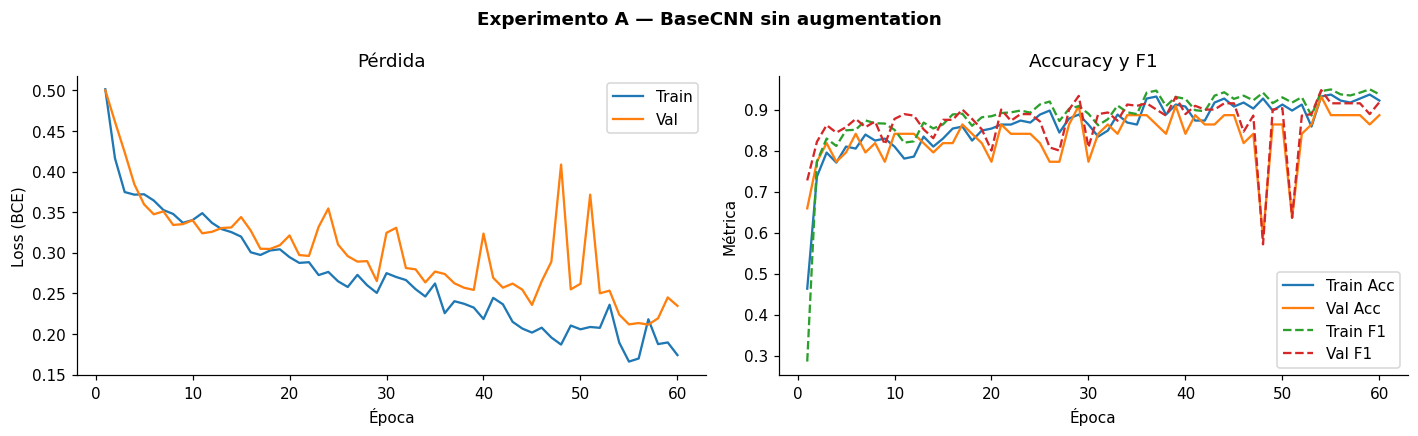

In [ ]:
# Curvas de entrenamiento
epochs_ran = range(1, len(history_A['train_loss']) + 1)

fig, axes = plt.subplots(1, 2, figsize=(13, 4))
fig.suptitle('Experimento A — BaseCNN sin augmentation', fontsize=12, fontweight='bold')

axes[0].plot(epochs_ran, history_A['train_loss'], label='Train')
axes[0].plot(epochs_ran, history_A['val_loss'],   label='Val')
axes[0].set_xlabel('Época'); axes[0].set_ylabel('Loss (BCE)')
axes[0].set_title('Pérdida'); axes[0].legend()

axes[1].plot(epochs_ran, history_A['train_acc'], label='Train Acc')
axes[1].plot(epochs_ran, history_A['val_acc'],   label='Val Acc')
axes[1].plot(epochs_ran, history_A['train_f1'],  label='Train F1', linestyle='--')
axes[1].plot(epochs_ran, history_A['val_f1'],    label='Val F1',   linestyle='--')
axes[1].set_xlabel('Época'); axes[1].set_ylabel('Métrica')
axes[1].set_title('Accuracy y F1'); axes[1].legend()

plt.tight_layout()
plt.show()

C:\Users\Pc\AppData\Local\Temp\ipykernel_14104\2054261919.py:8: FutureWarning: You are using `torch.load` with `weights_only=False` (the current default value), which uses the default pickle module implicitly. It is possible to construct malicious pickle data which will execute arbitrary code during unpickling (See https://github.com/pytorch/pytorch/blob/main/SECURITY.md#untrusted-models for more details). In a future release, the default value for `weights_only` will be flipped to `True`. This limits the functions that could be executed during unpickling. Arbitrary objects will no longer be allowed to be loaded via this mode unless they are explicitly allowlisted by the user via `torch.serialization.add_safe_globals`. We recommend you start setting `weights_only=True` for any use case where you don't have full control of the loaded file. Please open an issue on GitHub for any issues related to this experimental feature.
  model_A.load_state_dict(torch.load('model_A_best.pth', map_loca

Experimento A · Test
  Loss : 0.3493
  Acc  : 0.9111
  F1   : 0.9310
  AUC  : 0.8634

              precision    recall  f1-score   support

     No-Ship       0.93      0.82      0.88        17
        Ship       0.90      0.96      0.93        28

    accuracy                           0.91        45
   macro avg       0.92      0.89      0.90        45
weighted avg       0.91      0.91      0.91        45



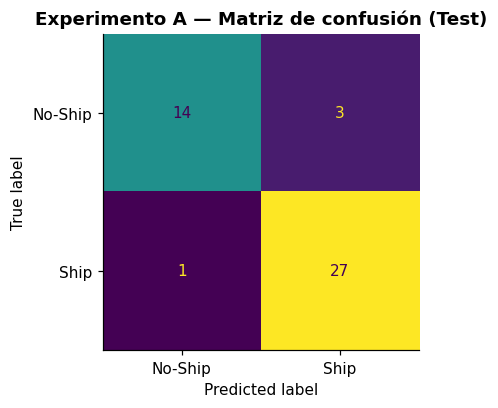

In [ ]:
from sklearn.metrics import classification_report, confusion_matrix, ConfusionMatrixDisplay

# Evaluación sobre test
test_ds_A   = PortDataset(test_df, label_col='ship', transform=transform_base)
test_loader_A = DataLoader(test_ds_A, batch_size=32, shuffle=False, num_workers=0)

# Cargamos el mejor checkpoint
model_A.load_state_dict(torch.load('model_A_best.pth', map_location=DEVICE))
te_loss, te_acc, te_f1, te_auc = eval_epoch(model_A, test_loader_A, criterion_A)

print(f"Experimento A · Test")
print(f"  Loss : {te_loss:.4f}")
print(f"  Acc  : {te_acc:.4f}")
print(f"  F1   : {te_f1:.4f}")
print(f"  AUC  : {te_auc:.4f}")

# Matriz de confusión
model_A.eval()
all_preds, all_labels = [], []
with torch.no_grad():
    for imgs, labels in test_loader_A:
        imgs = imgs.to(DEVICE)
        logits = model_A(imgs)
        preds = (torch.sigmoid(logits) >= 0.5).long().cpu().tolist()
        all_preds.extend(preds)
        all_labels.extend(labels.long().tolist())

print("\n" + classification_report(all_labels, all_preds, target_names=['No-Ship', 'Ship']))

cm = confusion_matrix(all_labels, all_preds)
fig, ax = plt.subplots(figsize=(4, 4))
ConfusionMatrixDisplay(cm, display_labels=['No-Ship', 'Ship']).plot(ax=ax, colorbar=False)
ax.set_title('Experimento A — Matriz de confusión (Test)', fontweight='bold')
plt.tight_layout()
plt.show()